# Feature Engineering

En este notebook se transforman los datos crudos en una matriz de features que se usarán para realizar el entrenamiento del modelo.

### Configuración y carga de datos

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 40)

TARGET = "fraude"
df = pd.read_csv("../data/fraud_meli_dataset.csv", parse_dates=["fecha"])

df_fe = df.copy()
print("Dimensiones iniciales:", df_fe.shape)

Dimensiones iniciales: (150000, 19)


## Modificaciones a variables existentes

Se realizan algunas transformaciones a las variables que se encuentran en el dataset.

### Eliminar `k`

De los análisis realizados se identificó que `k` es un identificador único con correlación de ~0 con la variable fraude, así que no aporta señal y se descarta.

In [2]:
df_fe = df_fe.drop(columns="k")

### Transformación logarítmica de `monto`

El monto tiene una distribución muy asimétrica, por lo que para estandarizar su distribución se usa `log_monto`. Sin embargo, la variable `monto` se conservar para poder calcular la ganancia
económica, que se usará como métrica de negocio.

In [3]:
df_fe["log_monto"] = np.log1p(df_fe["monto"]) # Se usa log1p para manejo seguro de valores cercanos a 0
df_fe[["monto", "log_monto"]].describe().round(2)

,monto,log_monto
count,150000.00,150000.00
mean,43.52,3.11
std,91.56,1.06
min,0.02,0.02
25%,9.38,2.34
50%,20.61,3.07
75%,40.69,3.73
max,3696.35,8.22


### Agrupación de países menos representados en `g`

En el EDA se notó que solo 4 países (BR, AR, US, UY) superan los 500 casos y cubren ~99% de las transacciones. Mientras que el resto son países con muy pocos registros, que se puede interpretar como ruido. Por lo tanto, estos países con menos observaciones se agrupan en una categoría `"OTROS"`.

In [4]:
MIN_CASOS_PAIS = 500
casos_por_pais = df_fe["g"].value_counts()
paises_frecuentes = casos_por_pais[casos_por_pais >= MIN_CASOS_PAIS].index

# Los países poco frecuentes (y los nulos) pasan a "OTROS"
df_fe["g"] = df_fe["g"].where(df_fe["g"].isin(paises_frecuentes), other="OTROS")
df_fe["g"].value_counts()

g
BR       111628
AR        31964
UY         2967
US         2273
OTROS      1168
Name: count, dtype: int64

### Frequency encoding de `j`

Dado que la variable `j` tiene ~8.300 categorías, no es factible usar one-hot encoder. Por lo que se reemplaza por la **frecuencia relativa** de cada categoría.

In [5]:
freq_j = df_fe["j"].value_counts(normalize=True)
df_fe["j_freq"] = df_fe["j"].map(freq_j)
df_fe = df_fe.drop(columns="j")
df_fe["j_freq"].describe().round(5)

count    150000.00000
mean          0.00184
std           0.00300
min           0.00001
25%           0.00017
50%           0.00060
75%           0.00203
max           0.01554
Name: j_freq, dtype: float64

### Recodificación de variables binarias
- `n` ya viene como 0/1, por lo que no se le aplica ningún cambio.
- Las variables `o` y `p` (`Y`/`N`) se mapean a 1/0. En `o` se conservan los `NaN` dado que su ausencia mostró ser informativa.
- Dado que en la variable `a` no se tiene certeza si importa el orden, se transforma con one-hot.

In [6]:
# Transformacion variables o y p
df_fe["o"] = df_fe["o"].map({"Y": 1, "N": 0})
df_fe["p"] = df_fe["p"].map({"Y": 1, "N": 0})

# Transformacion variable a
df_fe = pd.get_dummies(df_fe, columns=["a"], prefix="a")

df_fe.filter(regex="^(o|p|n|a_)").head()

,n,o,p,a_1,a_2,a_3,a_4
0,1,NaN,1,False,False,False,True
1,1,1.0,1,False,False,False,True
2,1,1.0,1,False,False,False,True
3,1,0.0,1,False,False,False,True
4,1,1.0,0,False,False,False,True


## Creación de nuevas variables

A partir de las variables existentes se generan nuevas features:
- Componentes temporales de la `fecha`. 
- Indicadores de ausencia para las variables cuya falta resultó informativa en el EDA.

### Variables temporales a partir de `fecha`

El EDA mostró una fuerte relación entre el fraude y el momento del día en el que se realizó la transacción. Por lo que, se derivan la hora, el día de la semana, si es fin de semana y si es madrugada. Se conserva la `fecha` porque se usará para el split de los datos de train, val y test.

In [7]:
# Extraccion de componentes de la fecha
df_fe["hora"] = df_fe["fecha"].dt.hour
df_fe["dia_semana"] = df_fe["fecha"].dt.dayofweek

# Indicador de madrugada (1-4 AM)
df_fe["madrugada"] = df_fe["hora"].between(1, 4).astype(int)

# Indicador de fin de semana
df_fe["fin_de_semana"] = (df_fe["dia_semana"] >= 5).astype(int)

df_fe[["fecha", "hora", "dia_semana", "madrugada", "fin_de_semana"]].head()

,fecha,hora,dia_semana,madrugada,fin_de_semana
0,2020-03-20 09:28:19,9,4,0,0
1,2020-03-09 13:58:28,13,0,0,0
2,2020-04-08 12:25:55,12,2,0,0
3,2020-03-14 11:46:13,11,5,0,1
4,2020-03-23 14:17:13,14,0,0,0


### Indicadores de ausencia

La ausencia de algunas variables mostró ser informativa, así que se marca con indicadores binarios en vez de imputarla. Para esto, primero se verifica si `b`/`c` y `d`/`m` comparten exactamente el mismo patrón de nulos.

In [8]:
# Verificacion: b/c y d/m comparten la misma mascara de nulos (mismas filas, no solo el conteo)
print("b y c comparten la mascara de nulos:", df_fe["b"].isna().equals(df_fe["c"].isna()))
print("d y m comparten la mascara de nulos:", df_fe["d"].isna().equals(df_fe["m"].isna()))

b y c comparten la mascara de nulos: True
d y m comparten la mascara de nulos: True


Con base en lo anterior, como `b`/`c` y `d`/`m` comparten exactamente el mismo patrón de nulos, basta con un indicador por grupo.

In [9]:
# Indicadores de ausencia para las variables cuya falta resulto informativa
df_fe["o_is_null"] = df_fe["o"].isna().astype(int)
df_fe["b_is_null"] = df_fe["b"].isna().astype(int)
df_fe["d_is_null"] = df_fe["d"].isna().astype(int)

df_fe[["o_is_null", "b_is_null", "d_is_null"]].mean().round(4)

o_is_null    0.7257
b_is_null    0.0866
d_is_null    0.0024
dtype: float64

## Baseline y feature importance

Por último, se entrena un modelo baseline y se mide la importancia de cada variable. El objetivo en este punto es únicamente validar con evidencia qué features aportan y cuáles conviene eliminar antes de la etapa de entrenamiento.

Para esto se usa un **HistGradientBoosting** y se mide la importancia con permutation importance sobre el set de validación.

### Split temporal

Dado que la señal temporal es fuerte con el fraude, los sets de datos se generan de manera que respeten el orden cronológico.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# Split cronologico: 80% mas antiguo a entrenamiento, 20% mas reciente a validacion
df_fe = df_fe.sort_values("fecha")
fecha_corte = df_fe["fecha"].quantile(0.80)

train = df_fe[df_fe["fecha"] < fecha_corte]
val = df_fe[df_fe["fecha"] >= fecha_corte]

print("Fecha de corte:", fecha_corte)
print("Train:", train.shape, "| Val:", val.shape)
print("Tasa de fraude  train:", round(train[TARGET].mean(), 4),
      "| val:", round(val[TARGET].mean(), 4))

Fecha de corte: 2020-04-14 18:59:28
Train: (120000, 29) | Val: (30000, 29)
Tasa de fraude  train: 0.0517 | val: 0.0431


### Construcción de la matriz de features

Se separan las features del target. Se excluyen `fecha` (solo se usó para el split) y `log_monto` (redundante para árboles). La única categórica que queda en texto, `g`, se convierte con one-hot.

In [11]:
# Columnas que no entran como feature al modelo
EXCLUIR = ["fecha", TARGET, "log_monto"]
features = [c for c in df_fe.columns if c not in EXCLUIR]

# one-hot de g
# Se alinean las columnas de val con las de train
X_train = pd.get_dummies(train[features], columns=["g"])
X_val = pd.get_dummies(val[features], columns=["g"]).reindex(columns=X_train.columns, fill_value=0)
y_train, y_val = train[TARGET], val[TARGET]

print("N° de features:", X_train.shape[1])

N° de features: 30


### Entrenamiento del baseline

Se entrena sin tuneo y con `class_weight="balanced"` para compensar el desbalance. Se reportan **PR-AUC** y ROC-AUC.

In [12]:
baseline = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
baseline.fit(X_train, y_train)

proba_val = baseline.predict_proba(X_val)[:, 1]
print("PR-AUC :", round(average_precision_score(y_val, proba_val), 4))
print("ROC-AUC:", round(roc_auc_score(y_val, proba_val), 4))

PR-AUC : 0.4246
ROC-AUC: 0.8834


### Permutation importance

Se mide cuánto cae el PR-AUC al permutar aleatoriamente cada variable: a mayor caída, más importante es la variable para el modelo.

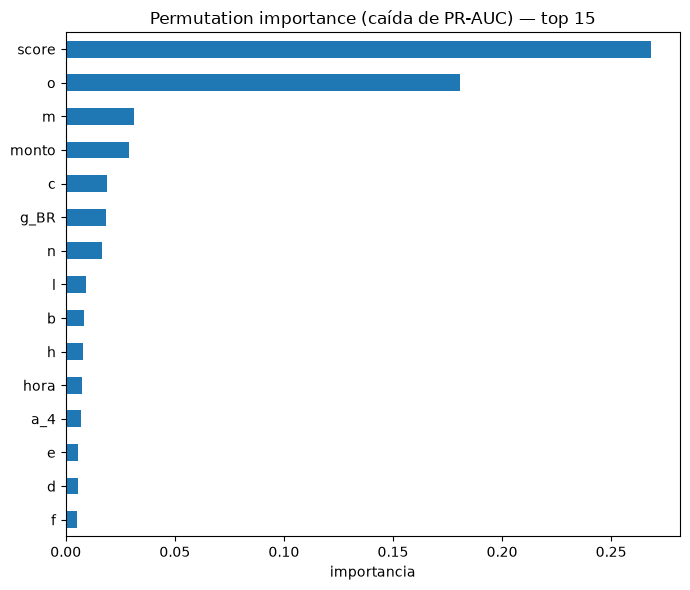

In [13]:
pi = permutation_importance(
    baseline, X_val, y_val,
    scoring="average_precision", n_repeats=5, random_state=42, n_jobs=-1,
)
importancia = pd.Series(pi.importances_mean, index=X_val.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importancia.head(15).iloc[::-1].plot.barh(ax=ax)
ax.set_title("Permutation importance (caída de PR-AUC) — top 15")
ax.set_xlabel("importancia")
plt.tight_layout(); plt.show()

### Análisis: De los resultados anteriores se puede notar que:
- **`score`** es la variable más relevante para el Fraude. Por ende, como se menciona anteriormente, es importante verificar que la variable `score` esté disponible en producción.
- **`o`** es la segunda variable más fuerte. Nótese que sus indicadores de ausencia (`o_is_null`, `b_is_null`, `d_is_null`) quedan con importancia ~0. Esto se debe a que con un modelo que maneja `NaN` nativamente, el indicador es redundante porque el propio modelo ya aprovecha la ausencia.
- Aportan señal moderada `m`, `monto`, `g_BR`, `c`, `l`, `n`, `h` y la `hora`.
- Aportan poco o nada `dia_semana`, los dummies `a_*` y los `*_is_null`.

**Conclusión del feature engineering:** el conjunto de features queda validado. Para árboles se podría simplificar quitando los indicadores *_is_null y variables de importancia nula, pero
la decisión final sobre cuáles variables mantener se define en el siguiente notebook `03_modeling.ipynb`.

## 4. Guardado del dataset procesado

Se guarda el resultado del feature engineering para usarlo directamente en el notebook de
modelado. El preprocesamiento específico de cada modelo (imputación, escalado) se hará dentro de
los pipelines, ajustado solo sobre el set de entrenamiento.

In [14]:
from pathlib import Path

ruta_salida = Path("../data/processed")
ruta_salida.mkdir(parents=True, exist_ok=True)
df_fe.to_parquet(ruta_salida / "fraud_fe.parquet", index=False)
print("Dataset procesado guardado:", df_fe.shape)

Dataset procesado guardado: (150000, 29)
